In [1]:
import os
os.getcwd()

'/Users/sam/Desktop/VScode/LLM/AAI/AgenticAI-2025/AI-2026/Week3'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

In [3]:
ls

BikeSharingData_EDA.csv*     bikerental_EDA.ipynb*
BikeSharingData_Upgrad.xlsx*


In [2]:
# Load The Data
columns = ['count', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'year', 'month', 'day', 'dayofweek','hour']

In [23]:
#df = pd.read_csv('bike_Sharing_data/train.csv')
df = pd.read_csv('BikeSharingData.csv')
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [6]:
df = pd.read_excel("BikeSharingData_Upgrad.xlsx")
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2012-12-19 23:00:00,4,0,1,1,13.12,16.665,66,8.9981,4,84,88
1,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129
2,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
3,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
4,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336


In [24]:
## EDA

In [7]:
df.isna().sum()

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

In [8]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
datetime,2734,2012-05-11 03:42:39.765910784,2011-10-01 00:00:00,2011-11-10 12:15:00,2012-05-10 23:30:00,2012-11-10 11:45:00,2012-12-19 23:00:00,NaN
season,2734.0,4.0,4.0,4.0,4.0,4.0,4.0,0.0
holiday,2734.0,0.035113,0.0,0.0,0.0,0.0,1.0,0.1841
workingday,2734.0,0.675201,0.0,0.0,1.0,1.0,1.0,0.468385
weather,2734.0,1.459766,1.0,1.0,1.0,2.0,3.0,0.642749
temp,2734.0,16.649239,5.74,13.12,16.4,20.5,30.34,4.742176
atemp,2734.0,20.059909,7.575,15.91,20.455,24.24,34.09,5.264197
humidity,2734.0,66.173738,16.0,52.0,66.0,81.0,100.0,17.813446
windspeed,2734.0,11.678147,0.0,7.0015,11.0014,16.9979,43.0006,7.842632
casual,2734.0,28.580834,0.0,4.0,14.0,33.0,362.0,42.596214


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2734 entries, 0 to 2733
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    2734 non-null   datetime64[ns]
 1   season      2734 non-null   int64         
 2   holiday     2734 non-null   int64         
 3   workingday  2734 non-null   int64         
 4   weather     2734 non-null   int64         
 5   temp        2734 non-null   float64       
 6   atemp       2734 non-null   float64       
 7   humidity    2734 non-null   int64         
 8   windspeed   2734 non-null   float64       
 9   casual      2734 non-null   int64         
 10  registered  2734 non-null   int64         
 11  count       2734 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(8)
memory usage: 256.4 KB


In [10]:
# We need to convert datetime to numeric for training.
# Let's extract key features into separate numeric columns
def add_features(df):
    df['month'] = pd.to_datetime(df['datetime']).dt.month
    df['Year'] = pd.to_datetime(df['datetime']).dt.year
    df['Day'] = pd.to_datetime(df['datetime']).dt.day
    df['Hour'] = pd.to_datetime(df['datetime']).dt.hour
    return df

In [11]:
df = add_features(df)
#add_features(df_test)
df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,Year,Day,Hour
0,2012-12-19 23:00:00,4,0,1,1,13.12,16.665,66,8.9981,4,84,88,12,2012,19,23
1,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129,12,2012,19,22
2,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,12,2012,19,21
3,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,12,2012,19,20
4,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,12,2012,19,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2729,2011-10-01 04:00:00,4,0,0,1,18.04,21.970,58,27.9993,2,6,8,10,2011,1,4
2730,2011-10-01 03:00:00,4,0,0,1,18.86,22.725,59,27.9993,8,17,25,10,2011,1,3
2731,2011-10-01 02:00:00,4,0,0,1,18.86,22.725,63,27.9993,21,46,67,10,2011,1,2
2732,2011-10-01 01:00:00,4,0,0,1,19.68,23.485,67,22.0028,11,47,58,10,2011,1,1


In [12]:
df['day_of_week'] = pd.to_datetime(df['datetime']).dt.dayofweek
days = {0:'Mon',1:'Tue',2:'Wed',3:'Thur',4:'Fri',5:'Sat',6:'Sun'}
df['day_of_week'] = df['day_of_week'].apply(lambda x: days[x])
df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,Year,Day,Hour,day_of_week
0,2012-12-19 23:00:00,4,0,1,1,13.12,16.665,66,8.9981,4,84,88,12,2012,19,23,Wed
1,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129,12,2012,19,22,Wed
2,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,12,2012,19,21,Wed
3,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,12,2012,19,20,Wed
4,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,12,2012,19,19,Wed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2729,2011-10-01 04:00:00,4,0,0,1,18.04,21.970,58,27.9993,2,6,8,10,2011,1,4,Sat
2730,2011-10-01 03:00:00,4,0,0,1,18.86,22.725,59,27.9993,8,17,25,10,2011,1,3,Sat
2731,2011-10-01 02:00:00,4,0,0,1,18.86,22.725,63,27.9993,21,46,67,10,2011,1,2,Sat
2732,2011-10-01 01:00:00,4,0,0,1,19.68,23.485,67,22.0028,11,47,58,10,2011,1,1,Sat


In [13]:
import calendar
df['month'] = df['month'].apply(lambda x: calendar.month_abbr[x])
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,Year,Day,Hour,day_of_week
0,2012-12-19 23:00:00,4,0,1,1,13.12,16.665,66,8.9981,4,84,88,Dec,2012,19,23,Wed
1,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129,Dec,2012,19,22,Wed
2,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,Dec,2012,19,21,Wed
3,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,Dec,2012,19,20,Wed
4,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,Dec,2012,19,19,Wed


In [14]:
print(df['month'].value_counts())
print(df['day_of_week'].value_counts())

month
Dec    912
Nov    911
Oct    911
Name: count, dtype: int64
day_of_week
Mon     408
Sat     408
Tue     384
Sun     384
Fri     384
Wed     383
Thur    383
Name: count, dtype: int64


In [15]:
# Working day usage
df['workingday'].value_counts()

workingday
1    1846
0     888
Name: count, dtype: int64

In [16]:
df['weather'].value_counts()

weather
1    1702
2     807
3     225
Name: count, dtype: int64

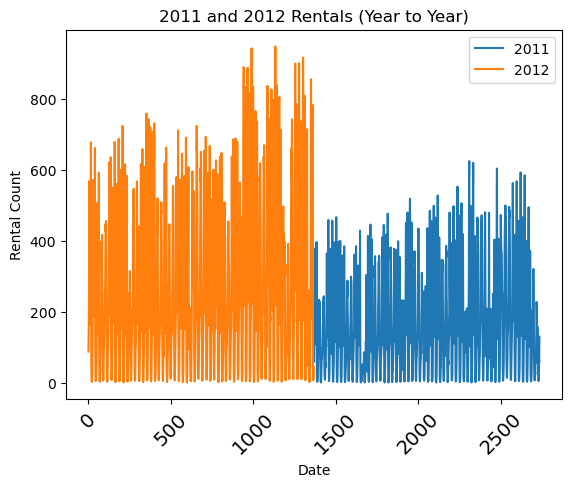

In [17]:
#plt.plot(df['2011']['count'],label='2011')


plt.plot(df[df['Year'] == 2011]['count'] , label = '2011')
plt.plot(df[df['Year'] == 2012]['count'] , label = '2012')
plt.xticks(fontsize=14, rotation=45)
plt.xlabel('Date')
plt.ylabel('Rental Count')
plt.title('2011 and 2012 Rentals (Year to Year)')
plt.legend()
plt.show()

In [18]:
df.head(2)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,Year,Day,Hour,day_of_week
0,2012-12-19 23:00:00,4,0,1,1,13.12,16.665,66,8.9981,4,84,88,Dec,2012,19,23,Wed
1,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129,Dec,2012,19,22,Wed


In [19]:
#df['date'] = pd.to_datetime(df['datetime']).dt.month
df['date'] = pd.to_datetime(df['datetime']).dt.date
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,Year,Day,Hour,day_of_week,date
0,2012-12-19 23:00:00,4,0,1,1,13.12,16.665,66,8.9981,4,84,88,Dec,2012,19,23,Wed,2012-12-19
1,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129,Dec,2012,19,22,Wed,2012-12-19
2,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,Dec,2012,19,21,Wed,2012-12-19
3,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,Dec,2012,19,20,Wed,2012-12-19
4,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,Dec,2012,19,19,Wed,2012-12-19


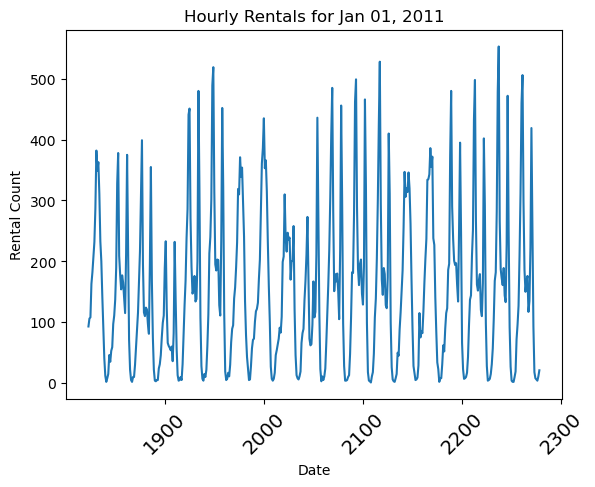

In [21]:

# Rentals change hourly!
plt.plot(df[(df['Year'] == 2011) & (df['month'] == 'Nov')]['count'])
plt.xticks(fontsize=14, rotation=45)
plt.xlabel('Date')
plt.ylabel('Rental Count')
plt.title('Hourly Rentals for Jan 01, 2011')
plt.show()

In [22]:
monthrange  = df['month']
monthrange = list(set(monthrange))

In [23]:
monthrange

['Dec', 'Oct', 'Nov']

/var/folders/m8/lr5c6v793qbcszm54dsf6y440000gn/T/ipykernel_2133/2867892914.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


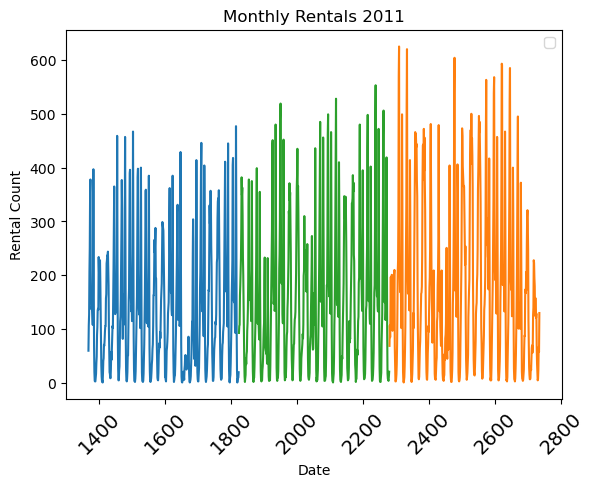

In [24]:
""" Monthly  review"""

# Rentals change hourly!
for each in monthrange:
    plt.plot(df[(df['Year'] == 2011) & (df['month'] == each)]['count'])

plt.xticks(fontsize=14, rotation=45)
plt.xlabel('Date')
plt.ylabel('Rental Count')
plt.title('Monthly Rentals 2011')
plt.legend()
plt.show()

For the Month Dec


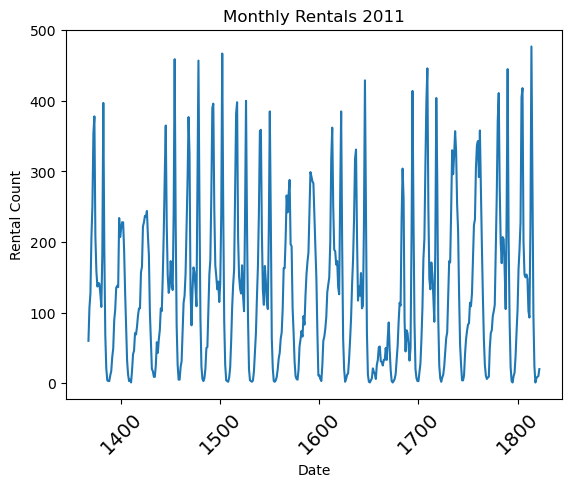

For the Month Oct


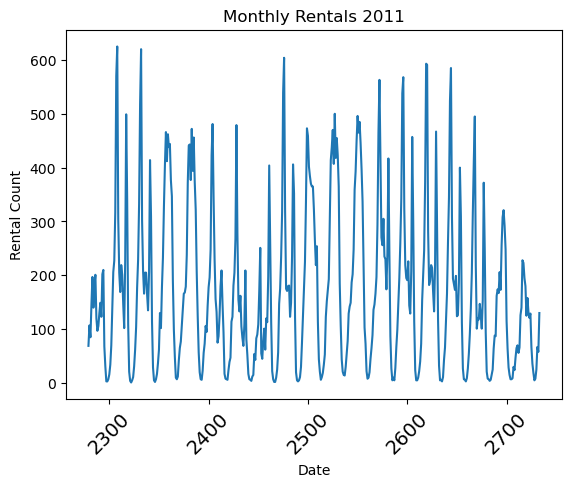

For the Month Nov


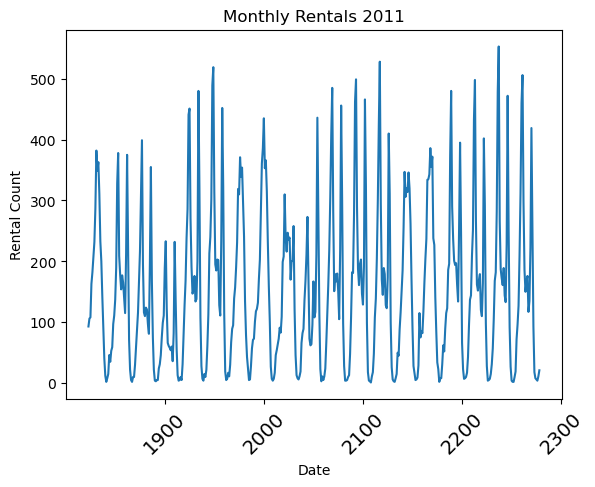

In [25]:
""" Monthly  review"""

# Rentals change hourly!
for each in monthrange:
    print("For the Month", each)
    plt.plot(df[(df['Year'] == 2011) & (df['month'] == each)]['count'])
    plt.xticks(fontsize=14, rotation=45)
    plt.xlabel('Date')
    plt.ylabel('Rental Count')
    plt.title('Monthly Rentals 2011')
    plt.show()